# 07 - Avaliação Final no Teste

Até aqui escolhi tudo sem olhar o teste: o algoritmo no notebook 05 e os
ajustes no notebook 06. Agora uso o teste pela primeira vez.

Neste notebook eu:

- treino o modelo final com todo o treino e avalio no teste;
- confirmo no teste a comparação entre os algoritmos e o ganho das
  variáveis de histórico;
- vejo se o resultado se mantém ao longo dos meses e nos diferentes
  segmentos;
- salvo o modelo final.

O teste são as reservas com chegada a partir de 22/04/2017, que o modelo
nunca viu. É assim que o modelo seria usado de verdade: treinado com o
passado e aplicado no futuro.

## 1. Preparação

In [1]:
import sys
sys.path.append("..")
import json
import time
import warnings
from datetime import date
from pathlib import Path
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, average_precision_score, brier_score_loss,
                             confusion_matrix, roc_curve)
from xgboost import XGBClassifier

from src.preprocessing import (preparar, separar_treino_teste, VARIAVEIS_NUMERICAS,
                               VARIAVEIS_CATEGORICAS, VARIAVEIS_HISTORICO, ALVO)

pd.set_option("display.float_format", lambda x: f"{x:.3f}")
LIMIAR = 0.40   # escolhido no notebook 06

In [2]:
df = preparar(historico=True)
treino, teste = separar_treino_teste(df)
num_final = VARIAVEIS_NUMERICAS + VARIAVEIS_HISTORICO   # com as variáveis de histórico do notebook 06
variaveis = num_final + VARIAVEIS_CATEGORICAS

X_treino, y_treino = treino[variaveis], treino[ALVO]
X_teste, y_teste = teste[variaveis], teste[ALVO]
print("treino:", len(treino), "| teste:", len(teste), f"| cancelamento no teste: {y_teste.mean():.3f}")

preproc = ColumnTransformer([
    ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                      ("sc", StandardScaler())]), num_final),
    ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                      ("oh", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]),
     VARIAVEIS_CATEGORICAS),
])

treino: 95367 | teste: 23842 | cancelamento no teste: 0.409


## 2. O modelo final no teste

A configuração vem do notebook 06: XGBoost com 300 árvores, taxa de
aprendizado 0,1, profundidade 5 e subsample 0,9, com as variáveis de
histórico, sem peso para a classe de cancelamento, sem calibração extra e com
limiar de 0,4.

In [3]:
modelo_final = Pipeline([
    ("prep", clone(preproc)),
    ("xgb", XGBClassifier(n_estimators=300, learning_rate=0.1, max_depth=5, subsample=0.9,
                          eval_metric="logloss", random_state=42, n_jobs=4)),
])
inicio = time.time()
modelo_final.fit(X_treino, y_treino)
tempo_final = time.time() - inicio

prob_teste = modelo_final.predict_proba(X_teste)[:, 1]
pred_teste = (prob_teste >= LIMIAR).astype(int)

resultado = {
    "accuracy": accuracy_score(y_teste, pred_teste),
    "precision": precision_score(y_teste, pred_teste),
    "recall": recall_score(y_teste, pred_teste),
    "f1": f1_score(y_teste, pred_teste),
    "roc_auc": roc_auc_score(y_teste, prob_teste),
    "pr_auc": average_precision_score(y_teste, prob_teste),
    "brier": brier_score_loss(y_teste, prob_teste),
}
pd.Series(resultado)

accuracy    0.810
precision   0.748
recall      0.806
f1          0.776
roc_auc     0.902
pr_auc      0.868
brier       0.126
dtype: float64

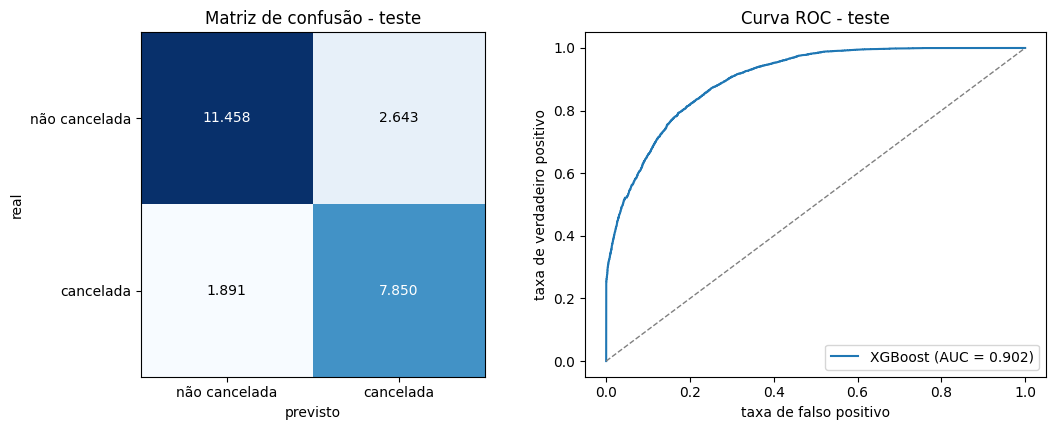

In [4]:
cm = confusion_matrix(y_teste, pred_teste)
fig, ax = plt.subplots(1, 2, figsize=(11, 4.4))

ax[0].imshow(cm, cmap="Blues")
for (i, j), v in np.ndenumerate(cm):
    ax[0].text(j, i, f"{v:,}".replace(",", "."), ha="center", va="center",
               color="white" if v > cm.max() / 2 else "black")
ax[0].set_xticks([0, 1], ["não cancelada", "cancelada"])
ax[0].set_yticks([0, 1], ["não cancelada", "cancelada"])
ax[0].set_xlabel("previsto")
ax[0].set_ylabel("real")
ax[0].set_title("Matriz de confusão - teste")

fpr, tpr, _ = roc_curve(y_teste, prob_teste)
ax[1].plot(fpr, tpr, label=f"XGBoost (AUC = {resultado['roc_auc']:.3f})")
ax[1].plot([0, 1], [0, 1], "--", color="gray", linewidth=1)
ax[1].set_xlabel("taxa de falso positivo")
ax[1].set_ylabel("taxa de verdadeiro positivo")
ax[1].set_title("Curva ROC - teste")
ax[1].legend()
plt.tight_layout()
plt.show()

In [5]:
# guarda a figura para o README (sobe uma pasta, entra em reports/figures)
fig.savefig("../reports/figures/avaliacao_teste.png")

No teste, com limiar de 0,4:

- o modelo avisa 7.850 dos 9.741 cancelamentos (recall 0,806);
- de cada 100 avisos, cerca de 75 são cancelamentos de verdade (precision
  0,748);
- a PR-AUC é 0,868, a ROC-AUC é 0,902 e o Brier é 0,126.

Esses números estão perto do que vi na validação: PR-AUC de 0,868 na
validação cruzada, e recall de 0,816 e precision de 0,745 no ajuste, com o
mesmo limiar. Não vejo sinal de sobreajuste.

A acurácia (0,810) aparece só como referência.

## 3. Qual modelo é o melhor no teste?

A escolha do XGBoost foi feita nos notebooks 05 e 06. Aqui só confirmo se a
ordem se mantém com dados novos. Treino todos os candidatos com o treino
inteiro e com as variáveis de histórico, cada um com a melhor configuração do
notebook 05, e avalio no teste. Também treino o mesmo XGBoost sem as
variáveis de histórico, para ver se o ganho do notebook 06 se mantém. Isso
não muda a escolha, só mostra se ela se confirma.

Além das métricas, conto quantos cancelamentos cada modelo pega com o mesmo
número de alertas do modelo final. Assim a comparação não depende do limiar
de cada modelo.

In [6]:
candidatos = {
    "regressão logística": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "árvore de decisão podada": DecisionTreeClassifier(min_samples_leaf=500, class_weight="balanced",
                                                       random_state=42),
    "random forest": RandomForestClassifier(n_estimators=200, class_weight="balanced",
                                            random_state=42, n_jobs=4),
    "gradient boosting": HistGradientBoostingClassifier(random_state=42),
    "rede neural (mlp)": MLPClassifier(hidden_layer_sizes=(32,), early_stopping=True, random_state=42),
}

probs = {"xgboost (modelo final)": prob_teste}
tempos = {"xgboost (modelo final)": tempo_final}
for nome, m in candidatos.items():
    inicio = time.time()
    pipe = Pipeline([("prep", clone(preproc)), ("modelo", m)]).fit(X_treino, y_treino)
    tempos[nome] = time.time() - inicio
    probs[nome] = pipe.predict_proba(X_teste)[:, 1]

# o mesmo xgboost sem as variáveis de histórico, para ver o ganho também no teste
base = VARIAVEIS_NUMERICAS + VARIAVEIS_CATEGORICAS
preproc_base = ColumnTransformer([
    ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                      ("sc", StandardScaler())]), VARIAVEIS_NUMERICAS),
    ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                      ("oh", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]),
     VARIAVEIS_CATEGORICAS),
])
inicio = time.time()
xgb_sem_hist = Pipeline([("prep", preproc_base), ("modelo", clone(modelo_final.named_steps["xgb"]))])
xgb_sem_hist.fit(treino[base], y_treino)
tempos["xgboost sem histórico"] = time.time() - inicio
probs["xgboost sem histórico"] = xgb_sem_hist.predict_proba(teste[base])[:, 1]

n_alertas = int(pred_teste.sum())
linhas = []
for nome, p in probs.items():
    top = np.zeros(len(p), dtype=int)
    top[np.argsort(-p)[:n_alertas]] = 1
    acertos = int(((top == 1) & (y_teste.values == 1)).sum())
    linhas.append({"modelo": nome,
                   "pr_auc": average_precision_score(y_teste, p),
                   "roc_auc": roc_auc_score(y_teste, p),
                   "brier": brier_score_loss(y_teste, p),
                   f"cancelamentos pegos ({n_alertas} alertas)": acertos,
                   "tempo_treino_s": tempos[nome]})

confirmacao = pd.DataFrame(linhas).set_index("modelo").sort_values("pr_auc", ascending=False)
confirmacao

,pr_auc,roc_auc,brier,cancelamentos pegos (10493 alertas),tempo_treino_s
modelo,,,,,
gradient boosting,0.868,0.902,0.126,7863,12.717
xgboost (modelo final),0.868,0.902,0.126,7850,10.488
random forest,0.862,0.898,0.137,7791,25.981
xgboost sem histórico,0.849,0.889,0.141,7693,9.255
rede neural (mlp),0.842,0.878,0.148,7552,27.897
regressão logística,0.829,0.869,0.147,7485,5.415
árvore de decisão podada,0.812,0.868,0.155,7385,5.848


No teste, o XGBoost e o gradient boosting ficam empatados, como na validação:
os dois têm PR-AUC 0,868, ROC-AUC 0,902 e Brier 0,126, e com o mesmo número
de alertas pegam 7.850 e 7.863 cancelamentos. Os dois ficam acima dos outros
modelos.

As variáveis de histórico também ajudam no teste. O mesmo XGBoost sem elas
fica com PR-AUC 0,849 e Brier 0,141, e pega 157 cancelamentos a menos com o
mesmo número de alertas (7.693 contra 7.850).

Sigo com o XGBoost, que é o que escolhi no notebook 05 e ajustei no notebook
06. O teste serve para confirmar essa escolha, então um empate aqui não é
motivo para trocar. Para mim ele também é o mais útil: a probabilidade dele é
confiável (importante para somar as probabilidades, como pensei no notebook
01) e ele treina em poucos segundos, então dá para treinar de novo com
frequência. Se o hotel precisar de um modelo mais fácil de explicar, a
regressão logística é uma alternativa, mas com uma perda maior: pega 365
cancelamentos a menos com o mesmo número de alertas.

## 4. O resultado se mantém ao longo do tempo?

Separo o teste por mês de chegada. Se o resultado cair muito com o tempo, o
modelo precisaria ser treinado de novo com frequência.

In [7]:
teste = teste.copy()
teste["prob"] = prob_teste

def metricas_grupo(g):
    prob, y = g["prob"], g[ALVO]
    pred = (prob >= LIMIAR).astype(int)
    return pd.Series({
        "reservas": len(g),
        "taxa_cancel": y.mean(),
        "recall": recall_score(y, pred, zero_division=0),
        "precision": precision_score(y, pred, zero_division=0),
        "roc_auc": roc_auc_score(y, prob) if y.nunique() == 2 else np.nan,
        "pr_auc": average_precision_score(y, prob) if y.nunique() == 2 else np.nan,
    })

teste["mes"] = teste["arrival_date"].dt.to_period("M").astype(str)
por_mes = teste.groupby("mes").apply(metricas_grupo)
por_mes

,reservas,taxa_cancel,recall,precision,roc_auc,pr_auc
mes,,,,,,
2017-04,1665.000,0.446,0.855,0.823,0.939,0.930
2017-05,6305.000,0.438,0.835,0.802,0.926,0.912
2017-06,5639.000,0.432,0.807,0.777,0.910,0.896
2017-07,5310.000,0.374,0.783,0.693,0.877,0.801
2017-08,4923.000,0.368,0.765,0.670,0.862,0.765


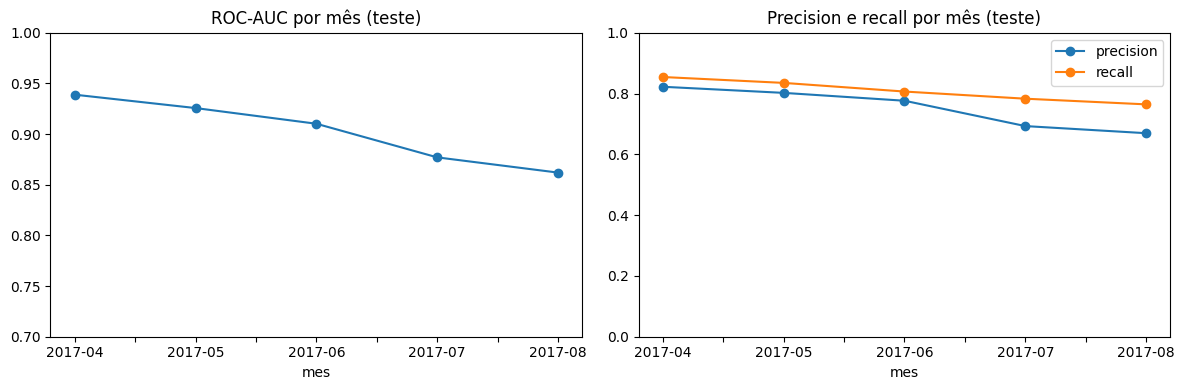

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
por_mes["roc_auc"].plot(marker="o", ax=ax[0], title="ROC-AUC por mês (teste)")
ax[0].set_ylim(0.7, 1.0)
por_mes[["precision", "recall"]].plot(marker="o", ax=ax[1], title="Precision e recall por mês (teste)")
ax[1].set_ylim(0, 1)
plt.tight_layout()
plt.show()

A ROC-AUC cai de 0,939 em abril para 0,862 em agosto. A queda é gradual e
nenhum mês fica perto do acaso (0,5), mas o modelo vai perdendo força quanto
mais longe fica do período de treino. A PR-AUC cai mais (de 0,930 para
0,765), em parte porque em julho e agosto também se cancela menos. Na
prática, o hotel teria que treinar o modelo de novo de tempos em tempos, por
exemplo a cada três meses.

## 5. Resultado por segmento

Um modelo pode ir bem na média e mal em algum grupo importante. Olho os
principais segmentos (só os que têm pelo menos 100 reservas no teste).

In [9]:
for coluna in ["hotel", "deposit_type", "market_segment", "customer_type"]:
    tab = teste.groupby(coluna).apply(metricas_grupo)
    print(tab[tab["reservas"] >= 100].round(3))
    print()

              reservas  taxa_cancel  recall  precision  roc_auc  pr_auc
hotel                                                                  
City Hotel   16363.000        0.432   0.803      0.747    0.890   0.872
Resort Hotel  7479.000        0.357   0.812      0.752    0.922   0.852

              reservas  taxa_cancel  recall  precision  roc_auc  pr_auc
deposit_type                                                           
No Deposit   21528.000        0.345   0.746      0.677    0.871   0.756
Non Refund    2292.000        1.000   1.000      1.000    1.000   1.000



                reservas  taxa_cancel  recall  precision  roc_auc  pr_auc
market_segment                                                           
Complementary    105.000        0.143   0.133      0.500    0.647   0.323
Corporate        640.000        0.242   0.710      0.791    0.933   0.868
Direct          2645.000        0.183   0.410      0.485    0.806   0.489
Groups          2686.000        0.671   0.997      0.927    0.995   0.998
Offline TA/TO   3778.000        0.344   0.968      0.858    0.984   0.968
Online TA      13916.000        0.429   0.750      0.686    0.828   0.764

                 reservas  taxa_cancel  recall  precision  roc_auc  pr_auc
customer_type                                                             
Contract          526.000        0.127   0.970      0.903    0.992   0.946
Group             116.000        0.103   0.583      0.583    0.964   0.787
Transient       20140.000        0.454   0.800      0.757    0.886   0.872
Transient-Party  3060.000       

- hotel: o modelo funciona nos dois (ROC-AUC 0,890 no City Hotel e 0,922 no
  Resort Hotel), com recall e precision parecidos;
- tipo de depósito: nas reservas não reembolsáveis todas cancelam e acertar é
  fácil. Nas reservas sem depósito, que são 90% do teste, a PR-AUC é 0,756
  para uma taxa de cancelamento de 0,345. É nelas que o modelo realmente
  precisa trabalhar;
- segmento de mercado: Groups, Offline TA/TO e Corporate têm ROC-AUC de 0,93
  ou mais. O mais difícil é o Direct (PR-AUC 0,489), que cancela pouco e de
  um jeito menos previsível. O Online TA, o maior segmento, fica em 0,828 de
  ROC-AUC. O Complementary (cortesias) fica fraco (ROC-AUC 0,647), mas são só
  105 reservas;
- tipo de cliente: nenhum grupo fica perto do acaso.

## 6. As linhas repetidas mudam o resultado?

No notebook 03 decidi manter as linhas repetidas. Aqui confiro essa decisão:
treino o mesmo modelo sem elas e comparo no teste.

In [10]:
cols = [c for c in treino.columns if c not in ["arrival_date", "booking_date"]]
treino_sem_rep = treino.drop_duplicates(subset=cols)
print("treino:", len(treino), "| sem repetições:", len(treino_sem_rep))

modelo_sr = clone(modelo_final).fit(treino_sem_rep[variaveis], treino_sem_rep[ALVO])
prob_sr = modelo_sr.predict_proba(X_teste)[:, 1]

pd.DataFrame({
    "com repetições": [roc_auc_score(y_teste, prob_teste), average_precision_score(y_teste, prob_teste)],
    "sem repetições": [roc_auc_score(y_teste, prob_sr), average_precision_score(y_teste, prob_sr)],
}, index=["ROC-AUC", "PR-AUC"])

treino: 95367 | sem repetições: 66517


,com repetições,sem repetições
ROC-AUC,0.902,0.905
PR-AUC,0.868,0.871


Os resultados ficam bem parecidos (PR-AUC 0,868 com as repetições e 0,871
sem). A diferença é pequena e aparece no teste, então não uso isso para mudar
o modelo: se eu escolhesse olhando o teste, o resultado dele deixaria de ser
uma avaliação limpa. Mantenho a decisão do notebook 03.

## 7. Salvando o modelo final

Salvo o pipeline completo (pré-processamento e XGBoost juntos) e um arquivo
com a configuração e as métricas do teste. Assim posso usar o modelo depois
sem treinar de novo, do mesmo jeito que um sistema do hotel carregaria o
modelo pronto para dar uma nota às reservas novas.

In [11]:
pasta = Path("../models")
pasta.mkdir(exist_ok=True)

joblib.dump(modelo_final, pasta / "final_pipeline.joblib")

config = {
    "modelo": "XGBoost",
    "limiar": LIMIAR,
    "variaveis": variaveis,
    "treinado_em": str(date.today()),
    "metricas_teste": {k: round(float(v), 4) for k, v in resultado.items()},
}
(pasta / "final_config.json").write_text(json.dumps(config, indent=2, ensure_ascii=False))
config["metricas_teste"]

{'accuracy': 0.8098,
 'precision': 0.7481,
 'recall': 0.8059,
 'f1': 0.7759,
 'roc_auc': 0.9015,
 'pr_auc': 0.868,
 'brier': 0.1262}

## 8. Conclusões

- no teste, o modelo avisa 81% dos cancelamentos e 75% dos avisos estão
  certos (PR-AUC 0,868, ROC-AUC 0,902 e Brier 0,126);
- os resultados batem com a validação;
- as variáveis de histórico também melhoram o resultado no teste (a PR-AUC
  passa de 0,849 para 0,868);
- o XGBoost e o gradient boosting empatam também no teste, e sigo com o
  XGBoost, que é o mais útil;
- o resultado cai aos poucos com o tempo, então o modelo precisa ser treinado
  de novo de tempos em tempos;
- o segmento mais difícil é o Direct, e o trabalho principal do modelo está
  nas reservas sem depósito.

No próximo notebook vejo o que o modelo aprendeu e onde ele erra.